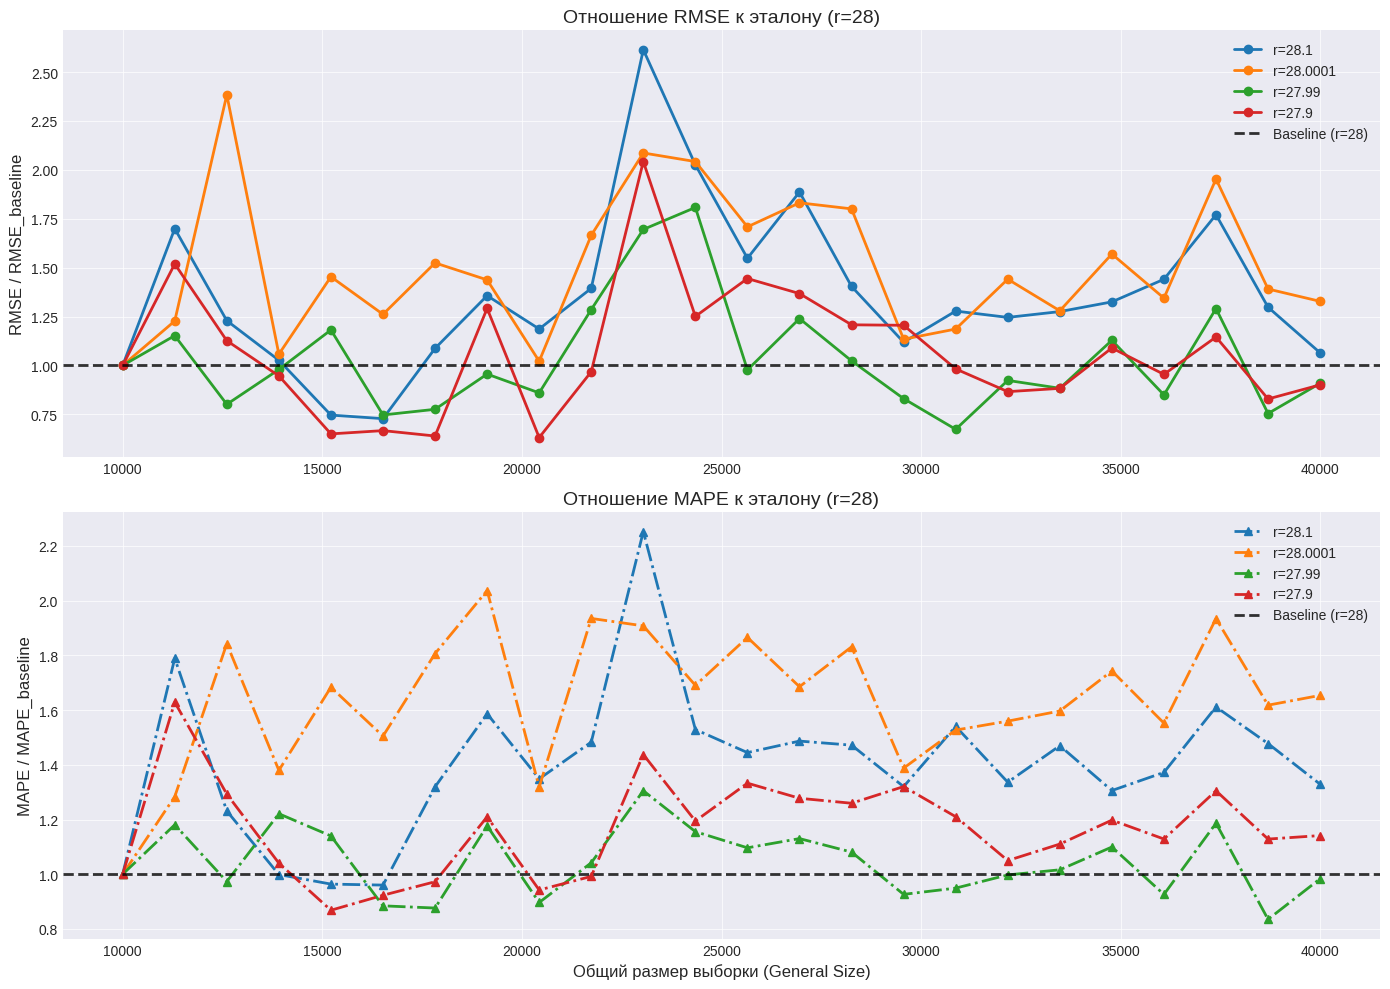

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. ЗАГРУЗКА И ФИЛЬТРАЦИЯ ДАННЫХ (остается без изменений)
df = pd.read_csv(
    'size_experiment_final_10.txt',
    header=None,
    names=[
        'deviation', 'arg', 'prediction_size', 'rmses',
        'np_points', 'mape', 'general_size'
    ]
)
exclude_deviations = [10, 2, 0.01, 0.001, -1]
df_filtered = df[~df['deviation'].isin(exclude_deviations)]
df_r28_all = df_filtered[df_filtered['deviation'] == 0]
df_r28 = df_r28_all[df_r28_all['general_size'] >= 10000]
df_others = df_filtered[df_filtered['deviation'] != 0]
df_filtered = pd.concat([df_r28, df_others])
deviations = df_filtered['deviation'].unique()

# 2. ПОДГОТОВКА ЭТАЛОННЫХ ДАННЫХ (r=28) ДЛЯ ИНТЕРПОЛЯЦИИ
# Важно: данные для интерполяции должны быть отсортированы по X
baseline_r28 = df_r28_all.sort_values('general_size')
baseline_sizes = baseline_r28['general_size'].values
baseline_rmses = baseline_r28['rmses'].values
baseline_mapes = baseline_r28['mape'].values

# 3. СОЗДАНИЕ ГРАФИКОВ
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plt.style.use('seaborn-v0_8-darkgrid')

# --- График 1: ОТНОШЕНИЕ RMSE ---
ax1 = axes[0]
for d in deviations:
    if d == 0: continue # Пропускаем сам эталонный ряд
    subset = df_filtered[df_filtered['deviation'] == d].sort_values('general_size')

    # Интерполируем эталонные значения RMSE для X-точек текущего ряда
    interpolated_baseline_rmses = np.interp(subset['general_size'], baseline_sizes, baseline_rmses)

    # Вычисляем отношение
    rmse_ratio = subset['rmses'] / interpolated_baseline_rmses

    ax1.plot(subset['general_size'], rmse_ratio, 'o-', linewidth=2, markersize=6, label=f'r={d+28}')

# Горизонтальная линия на уровне 1.0 соответствует эталону
ax1.axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Baseline (r=28)')
ax1.set_title('Отношение RMSE к эталону (r=28)', fontsize=14)
ax1.set_ylabel('RMSE / RMSE_baseline', fontsize=12)
ax1.grid(True, alpha=0.7)
ax1.legend()




# --- График 3: ОТНОШЕНИЕ MAPE ---
ax3 = axes[1]
for d in deviations:
    if d == 0: continue # Пропускаем сам эталонный ряд
    subset = df_filtered[df_filtered['deviation'] == d].sort_values('general_size')

    # Интерполируем эталонные значения MAPE для X-точек текущего ряда
    interpolated_baseline_mapes = np.interp(subset['general_size'], baseline_sizes, baseline_mapes)

    # Вычисляем отношение
    mape_ratio = subset['mape'] / interpolated_baseline_mapes

    ax3.plot(subset['general_size'], mape_ratio, '^-.', linewidth=2, markersize=6, label=f'r={d+28}')

# Горизонтальная линия на уровне 1.0 соответствует эталону
ax3.axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Baseline (r=28)')
ax3.set_title('Отношение MAPE к эталону (r=28)', fontsize=14)
ax3.set_xlabel('Общий размер выборки (General Size)', fontsize=12)
ax3.set_ylabel('MAPE / MAPE_baseline', fontsize=12)
ax3.grid(True, alpha=0.7)
ax3.legend()

plt.tight_layout()
plt.savefig('metrics_ratio_vs_general_size.png', dpi=300)
plt.show()

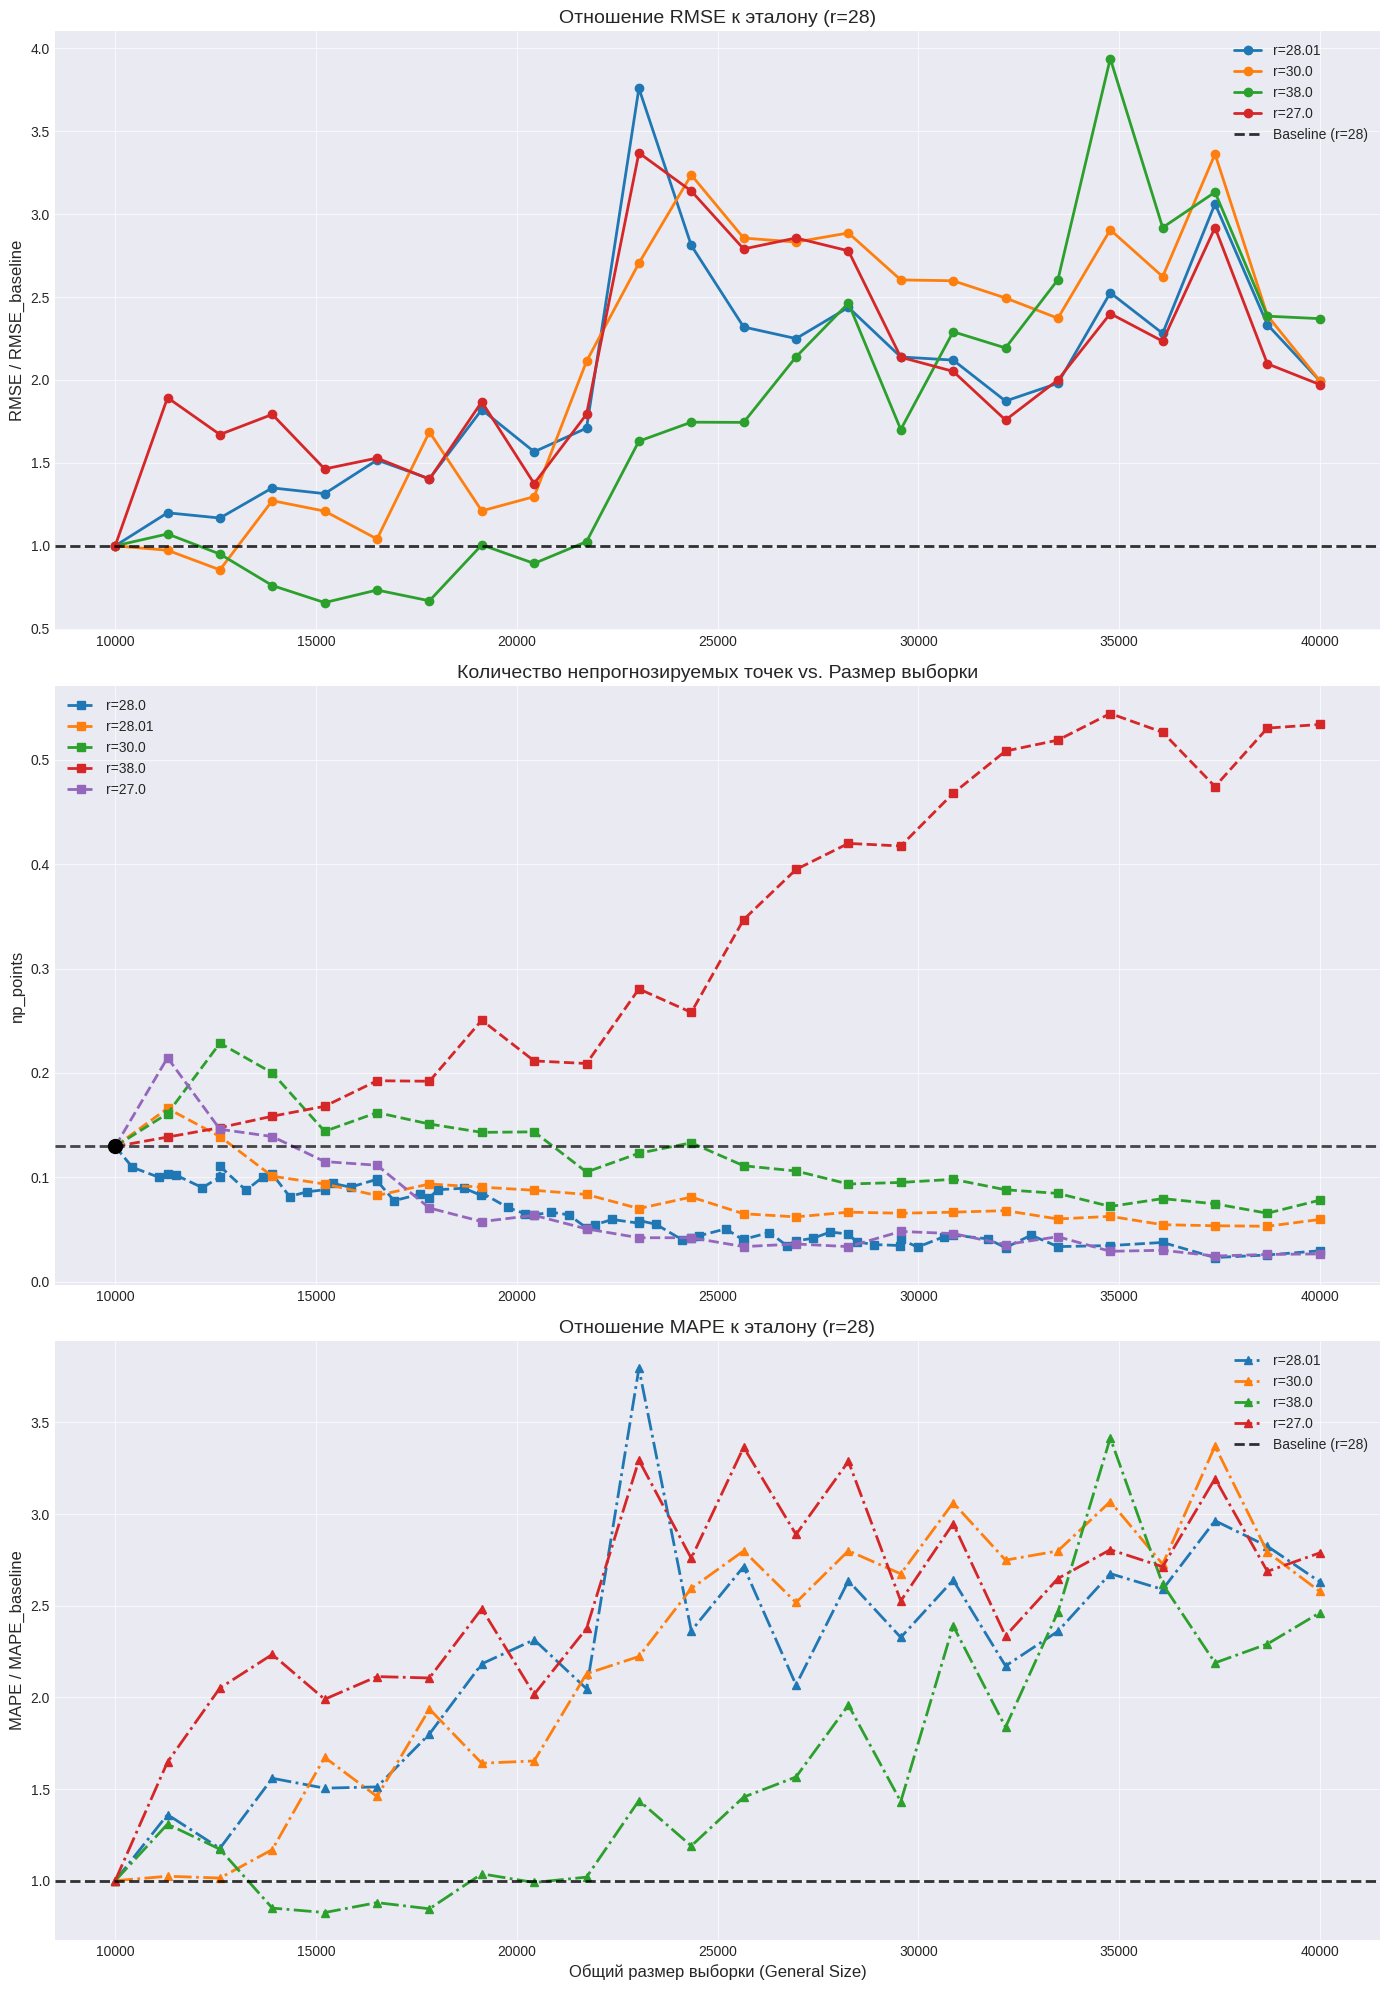

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. ЗАГРУЗКА И ФИЛЬТРАЦИЯ ДАННЫХ (остается без изменений)
df = pd.read_csv(
    'size_experiment_final_10.txt',
    header=None,
    names=[
        'deviation', 'arg', 'prediction_size', 'rmses',
        'np_points', 'mape', 'general_size'
    ]
)
# ВАЖНО: я убрал 0 из exclude_deviations, чтобы r=28 был доступен для сравнения.
# Если вы хотите построить график для других r, измените этот список.
exclude_deviations = [10, 2, 0.01, 0.001, -1,0]
df_filtered = df[df['deviation'].isin(exclude_deviations)]
df_r28_all = df[df['deviation'] == 0] # Берем все точки для r=28 для интерполяции
df_r28 = df_r28_all[df_r28_all['general_size'] >= 10000]
df_others = df_filtered[df_filtered['deviation'] != 0]
df_filtered = pd.concat([df_r28, df_others])
deviations = df_filtered['deviation'].unique()

# 2. ПОДГОТОВКА ЭТАЛОННЫХ ДАННЫХ (r=28) ДЛЯ ИНТЕРПОЛЯЦИИ
baseline_r28 = df_r28_all.sort_values('general_size')
baseline_sizes = baseline_r28['general_size'].values
baseline_rmses = baseline_r28['rmses'].values
baseline_mapes = baseline_r28['mape'].values
# Находим точку с r=28 и size=10000 для графика NP точек
reference_point = df_r28_all[df_r28_all['general_size'] == 10000].iloc[0]

# 3. СОЗДАНИЕ ГРАФИКОВ
# <<< ИЗМЕНЕНИЕ: Создаем сетку 3x1 и увеличиваем высоту фигуры
fig, axes = plt.subplots(3, 1, figsize=(14, 20))
plt.style.use('seaborn-v0_8-darkgrid')

# --- График 1: ОТНОШЕНИЕ RMSE ---
ax1 = axes[0]
for d in deviations:
    if d == 0: continue
    subset = df_filtered[df_filtered['deviation'] == d].sort_values('general_size')
    interpolated_baseline_rmses = np.interp(subset['general_size'], baseline_sizes, baseline_rmses)
    rmse_ratio = subset['rmses'] / interpolated_baseline_rmses
    ax1.plot(subset['general_size'], rmse_ratio, 'o-', linewidth=2, markersize=6, label=f'r={d+28}')

ax1.axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Baseline (r=28)')
ax1.set_title('Отношение RMSE к эталону (r=28)', fontsize=14)
ax1.set_ylabel('RMSE / RMSE_baseline', fontsize=12)
ax1.grid(True, alpha=0.7)
ax1.legend()

# <<< ИЗМЕНЕНИЕ: Добавлен блок для NP точек ---
ax2 = axes[1]
for d in deviations:
    subset = df_filtered[df_filtered['deviation'] == d].sort_values('general_size')
    # Здесь строим абсолютные значения
    ax2.plot(subset['general_size'], subset['np_points'], 's--', linewidth=2, markersize=6, label=f'r={d+28}')

# Добавляем горизонтальную линию и выделяем точку для np_points, как в старом коде
ax2.axhline(y=reference_point['np_points'], color='black', linestyle='--', linewidth=2, alpha=0.7)
ax2.plot(reference_point['general_size'], reference_point['np_points'], 'ko', markersize=10)
ax2.set_title('Количество непрогнозируемых точек vs. Размер выборки', fontsize=14)
ax2.set_ylabel('np_points', fontsize=12)
ax2.grid(True, alpha=0.7)
ax2.legend()

# --- График 3: ОТНОШЕНИЕ MAPE ---
# <<< ИЗМЕНЕНИЕ: Теперь рисуем на axes[2]
ax3 = axes[2]
for d in deviations:
    if d == 0: continue
    subset = df_filtered[df_filtered['deviation'] == d].sort_values('general_size')
    interpolated_baseline_mapes = np.interp(subset['general_size'], baseline_sizes, baseline_mapes)
    mape_ratio = subset['mape'] / interpolated_baseline_mapes
    ax3.plot(subset['general_size'], mape_ratio, '^-.', linewidth=2, markersize=6, label=f'r={d+28}')

ax3.axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Baseline (r=28)')
ax3.set_title('Отношение MAPE к эталону (r=28)', fontsize=14)
ax3.set_xlabel('Общий размер выборки (General Size)', fontsize=12)
ax3.set_ylabel('MAPE / MAPE_baseline', fontsize=12)
ax3.grid(True, alpha=0.7)
ax3.legend()

plt.tight_layout()
# <<< ИЗМЕНЕНИЕ: новое имя файла, отражающее содержимое
plt.savefig('metrics_comparison_with_ratios_unlucky.png', dpi=300)
plt.show()